## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Carlos Daniel Torres Macias
## Semestre: Enero_Junio del 2026

---
#### Practica 26: Ejemplo de Redes Neuronales Convolucionales (CNN) con CIFAR-10

La CNN se implementara para predecir imagenes de la base de datos CIFAR-10 (10 categorias de objetos del mundo real).

La base de datos CIFAR-10 (Canadian Institute for Advanced Research) es un conjunto de datos ampliamente utilizado en visión por computadora y aprendizaje automático. Contiene imágenes a color de 10 categorías de objetos, con las siguientes características:

* Cantidad de imágenes: 60,000 imágenes en total (50,000 para entrenamiento y 10,000 para prueba).
* Formato: imágenes en color RGB de 32x32 píxeles (3 canales).
* Etiquetas: cada imagen está etiquetada con una de las 10 clases: avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión.

A diferencia de MNIST (imágenes en escala de grises de dígitos), CIFAR-10 presenta un desafío mayor al contener imágenes a color con objetos del mundo real, lo que requiere una arquitectura CNN más robusta.

##### Paso 1: Importar las librerías

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import LeakyReLU

##### Paso 2: Cargar el conjunto de datos

In [3]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import plot_model

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Nombres de las clases del dataset CIFAR-10
class_names = ['avion', 'automovil', 'pajaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camion']

print("\nClases del dataset CIFAR-10:")
for i, name in enumerate(class_names):
    print(f"  Clase {i}: {name}")

print("\nPrimeras 8 etiquetas de entrenamiento:")
print([class_names[y_train[i][0]] for i in range(8)])

C:\Users\diego\AppData\Roaming\Python\Python313\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)

Clases del dataset CIFAR-10:
  Clase 0: avion
  Clase 1: automovil
  Clase 2: pajaro
  Clase 3: gato
  Clase 4: ciervo
  Clase 5: perro
  Clase 6: rana
  Clase 7: caballo
  Clase 8: barco
  Clase 9: camion

Primeras 8 etiquetas de entrenamiento:
['rana', 'camion', 'camion', 'ciervo', 'automovil', 'automovil', 'pajaro', 'caballo']


##### Paso 3: Graficar las imagenes del dataset CIFAR-10

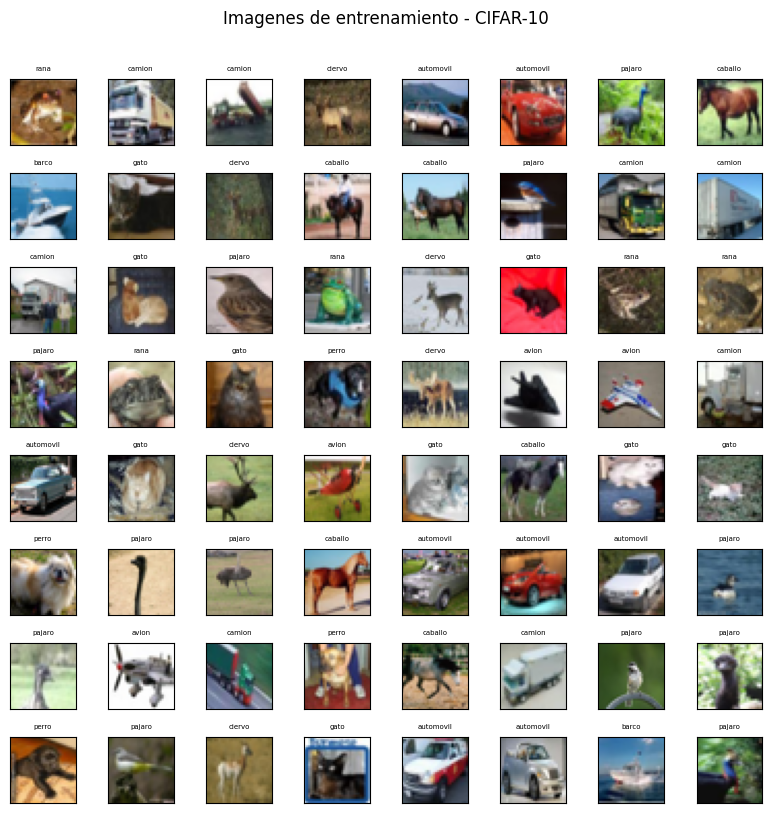

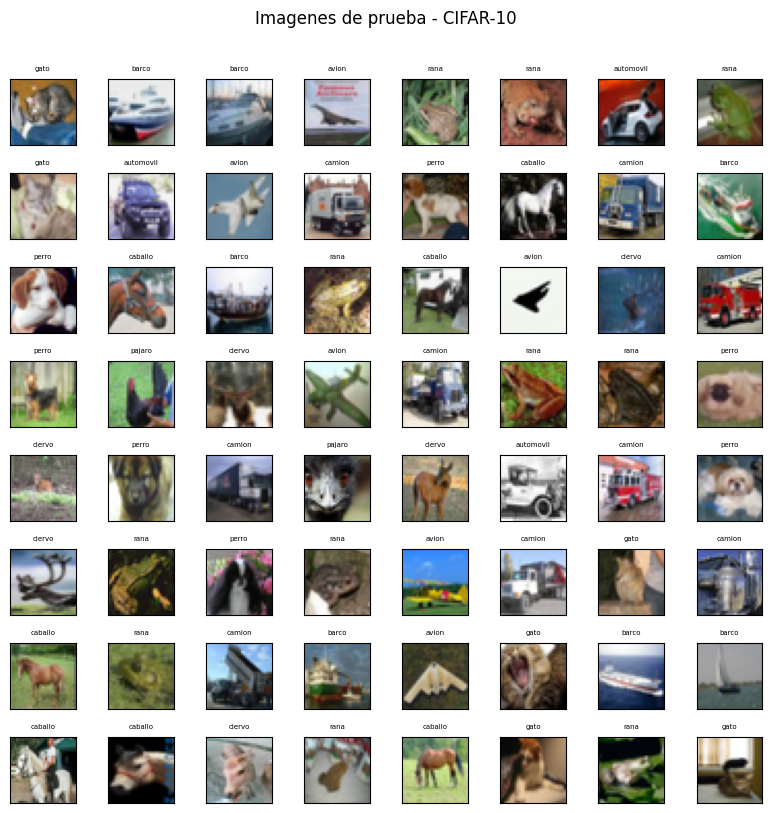

In [4]:
# Visualizacion de 64 imagenes del conjunto de entrenamiento
fig, ax = plt.subplots(8, 8, figsize=(8, 8), dpi=100)
fig.suptitle('Imagenes de entrenamiento - CIFAR-10', fontsize=12, y=1.01)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_train[i])
    axi.set_title(class_names[y_train[i][0]], fontsize=5)
    axi.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

# Visualizacion de 64 imagenes del conjunto de prueba
fig, ax = plt.subplots(8, 8, figsize=(8, 8), dpi=100)
fig.suptitle('Imagenes de prueba - CIFAR-10', fontsize=12, y=1.01)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i])
    axi.set_title(class_names[y_test[i][0]], fontsize=5)
    axi.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

##### Paso 4: Transformación de los datos

In [5]:
# Calculamos la cantidad de etiquetas
num_labels = len(np.unique(y_train))
print("Numero de etiquetas:", num_labels)

# Convertimos a forma one-hot vector
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print("\nPrimeras 8 etiquetas one-hot:")
print(y_train[0:8])

# Dimensiones de entrada de la imagen
image_size = X_train.shape[1]    # alto
image_width = X_train.shape[2]   # ancho
image_channels = X_train.shape[3]  # canales (3 para RGB)
print("\nDimensiones de la imagen:")
print(f"  Alto: {image_size}, Ancho: {image_width}, Canales: {image_channels}")

# Normalizar los datos al rango [0, 1]
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

print("\nFormas finales:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Numero de etiquetas: 10

Primeras 8 etiquetas one-hot:
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]

Dimensiones de la imagen:
  Alto: 32, Ancho: 32, Canales: 3

Formas finales:
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


##### Paso 5: Construir la estructura de la CNN

Dado que CIFAR-10 contiene imágenes a color (RGB) de 32×32 píxeles con mayor variabilidad visual que MNIST,
se utiliza una arquitectura más profunda con capas de BatchNormalization para estabilizar el entrenamiento.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Hiperparametros del modelo
input_shape = (image_size, image_width, image_channels)  # (32, 32, 3)
kernel_size = 3
pool_size = 2
filters = 64
dropout = 0.3

model = Sequential()

# Bloque 1: Dos capas convolucionales + MaxPooling
model.add(Conv2D(filters=filters,
                 kernel_size=kernel_size,
                 activation='relu',
                 padding='same',
                 input_shape=input_shape
                 ))
model.add(BatchNormalization())
model.add(Conv2D(filters=filters,
                 kernel_size=kernel_size,
                 activation='relu',
                 padding='same'
                 ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=pool_size))
model.add(Dropout(dropout))

# Bloque 2: Dos capas convolucionales + MaxPooling
model.add(Conv2D(filters=filters * 2,
                 kernel_size=kernel_size,
                 activation='relu',
                 padding='same'
                 ))
model.add(BatchNormalization())
model.add(Conv2D(filters=filters * 2,
                 kernel_size=kernel_size,
                 activation='relu',
                 padding='same'
                 ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=pool_size))
model.add(Dropout(dropout))

# Bloque 3: Capa convolucional adicional
model.add(Conv2D(filters=filters * 4,
                 kernel_size=kernel_size,
                 activation='relu',
                 padding='same'
                 ))
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Capa de clasificacion
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(128, activation='sigmoid'))

# Capa de salida
model.add(Dense(num_labels))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             

 Total params: 4,787,658 (18.26 MB)

 Trainable params: 4,785,866 (18.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

##### Paso 6: Configuración del modelo

In [8]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

##### Paso 7: Entrenamiento del modelo

In [9]:
batch_size = 128
epochs = 10

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.6005 - loss: 1.1301
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 377s 965ms/step - accuracy: 0.7402 - loss: 0.7444
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 377s 952ms/step - accuracy: 0.7945 - loss: 0.5937
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 356s 909ms/step - accuracy: 0.8301 - loss: 0.4916
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 365s 866ms/step - accuracy: 0.8578 - loss: 0.4130
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 392s 892ms/step - accuracy: 0.8807 - loss: 0.3420
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 340s 870ms/step - accuracy: 0.8994 - loss: 0.2909
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 331s 845ms/step - accuracy: 0.9139 - loss: 0.2456
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 333s 852ms/step - accuracy: 0.9253 - loss: 0.2133
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 339s 866ms/step - accuracy: 0.9324 - loss: 0.1938


In [10]:
salida, acc = model.evaluate(X_test, y_test, batch_size=batch_size, verbose=0)
print("Precisión Global en CIFAR-10: %.1f%%" % (acc * 100.0))

Precisión Global en CIFAR-10: 82.5%


##### Paso 8: Ejemplo de predicción de imagenes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
Indices predichos (fila): [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 6]
Predicciones 4x4:
[[3 8 8 0]
 [6 6 1 6]
 [3 1 0 9]
 [5 7 9 6]]


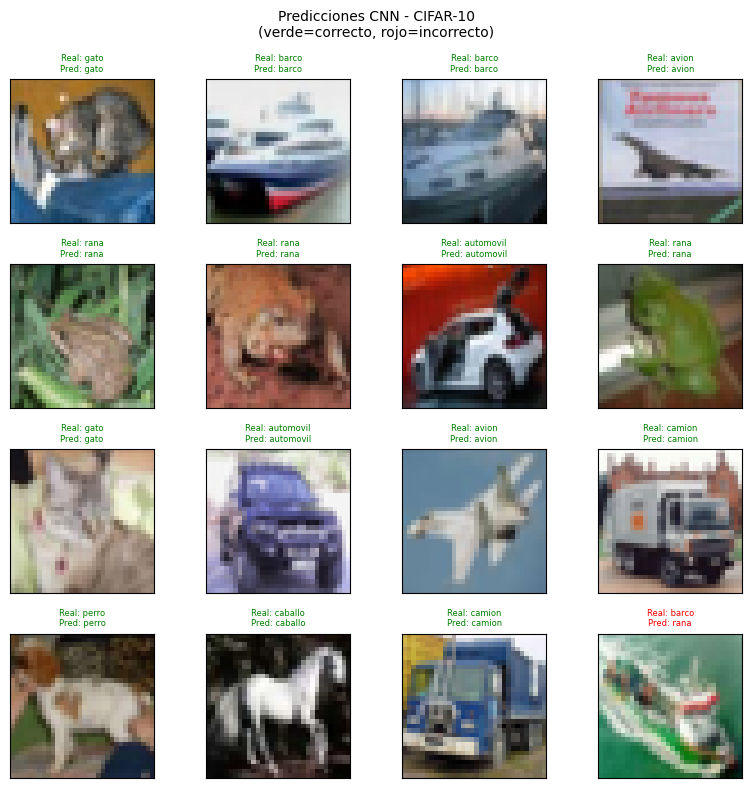

In [13]:
# Recargar los datos originales para visualizacion (sin normalizar)
(_, _), (X_test_orig, y_test_orig) = cifar10.load_data()

# Tomar las primeras 16 imagenes
n = 16
x_sample = X_test[:n]
y_real = [class_names[y_test_orig[i][0]] for i in range(n)]

# Realizar predicciones
pred_probs = model.predict(x_sample)
pred_classes = np.argmax(pred_probs, axis=-1)
pred_names = [class_names[p] for p in pred_classes]

print("Indices predichos (fila):", pred_classes)
print("Predicciones 4x4:")
print(np.reshape(pred_classes, [4, 4]))

# Visualizar predicciones vs etiquetas reales
fig, ax = plt.subplots(4, 4, figsize=(8, 8), dpi=100)
fig.suptitle('Predicciones CNN - CIFAR-10\n(verde=correcto, rojo=incorrecto)', fontsize=10)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test_orig[i])
    color = 'green' if pred_names[i] == y_real[i] else 'red'
    axi.set_title(f'Real: {y_real[i]}\nPred: {pred_names[i]}',
                  fontsize=6, color=color)
    axi.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

#### Conclusiones
##### En esta practica implementamos una Red Neuronal Convolucional (CNN) utilizando Keras y TensorFlow para clasificar imágenes del dataset CIFAR-10. A diferencia de la Práctica 25 que utilizó el dataset MNIST (dígitos en escala de grises de 28×28 píxeles), en esta práctica trabajamos con imágenes a color RGB de 32×32 píxeles de 10 categorías de objetos del mundo real (aviones, automóviles, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones).

##### La mayor complejidad de CIFAR-10 respecto a MNIST requirió adaptar la arquitectura: se incorporaron capas adicionales de BatchNormalization para estabilizar el entrenamiento, más filtros por capa convolucional (64, 128 y 256 respectivamente) y una capa densa más amplia (256 neuronas), lo que permite al modelo aprender características más ricas. La entrada ahora maneja 3 canales de color en lugar de 1.

##### Se observa que la precisión obtenida en CIFAR-10 es menor que en MNIST, lo cual es esperado debido a la mayor variabilidad visual de las imágenes a color con objetos del mundo real.

#### Bibliografia
##### URL: TensorFlow (2025) https://www.tensorflow.org/?hi=es-419 (último acceso abril de 2025).
##### URL: Keras (2025) https://keras.io/ (último acceso abril de 2025).
##### URL: CIFAR-10 Dataset (2025) https://www.cs.toronto.edu/~kriz/cifar.html (último acceso abril de 2025).
##### URL: BatchNormalization (2025) https://keras.io/api/layers/normalization_layers/batch_normalization/ (último acceso abril de 2025).